<a href="https://colab.research.google.com/github/aishanikar9/BWSI_Operations_Team/blob/main/BWSI_xView2_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import torch
import pandas as pd
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import pathlib


In [6]:
!pip install kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("tunguz/xview2-challenge-dataset-train-and-test")
print("Path to dataset files:", path)

import os

# View all files and folders in the downloaded path
files = os.listdir(path)
print(files)


Using Colab cache for faster access to the 'xview2-challenge-dataset-train-and-test' dataset.
Path to dataset files: /kaggle/input/xview2-challenge-dataset-train-and-test
['test', 'train']


In [7]:
# To inspect if folders are structures or archives, add this block:
for f in files:
    full_p = os.path.join(path, f)
    if os.path.isdir(full_p):
        print(f"Folder: {f} -> Contains: {os.listdir(full_p)}")
    else:
        print(f"File: {f}")


Folder: test -> Contains: ['test']
Folder: train -> Contains: ['train']


In [8]:
# Check the contents inside the nested folders
print("Inside train/train:", os.listdir(os.path.join(path, 'train', 'train')))
print("Inside test/test:", os.listdir(os.path.join(path, 'test', 'test')))


Inside train/train: ['labels', 'images']
Inside test/test: ['images']


In [9]:
!pip install shapely

first we find the bounding box of each building and crop them out into separate chips to make our new target dataset.

In [10]:
import os
import json
import cv2
import pandas as pd
import numpy as np
import kagglehub
from shapely.wkt import loads
from sklearn.model_selection import train_test_split
from tqdm import tqdm

path = kagglehub.dataset_download("tunguz/xview2-challenge-dataset-train-and-test")

train_dir = os.path.join(path, 'train', 'train')
train_image_dir = os.path.join(train_dir, 'images')
train_label_dir = os.path.join(train_dir, 'labels')

test_dir = os.path.join(path, 'test', 'test')
test_image_dir = os.path.join(test_dir, 'images')

output_crop_dir = '/content/cropped_building_chips'
os.makedirs(output_crop_dir, exist_ok=True)

damage_map = {'no-damage': 0, 'minor-damage': 1, 'major-damage': 2, 'destroyed': 3}
post_jsons = [f for f in os.listdir(train_label_dir) if f.endswith('_post_disaster.json')]

all_train_val_chips = []
crop_counter = 0

print("--- Step 1: Extracting Building Chips from Training Images ---")
for j_file in tqdm(post_jsons):
    img_file = j_file.replace('.json', '.png')
    img_path = os.path.join(train_image_dir, img_file)

    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue

    with open(os.path.join(train_label_dir, j_file)) as f:
        label_data = json.load(f)

    for feature in label_data['features']['xy']:
        wkt_string = feature['wkt']
        damage_type = feature['properties']['subtype']

        if damage_type not in damage_map:
            continue

        try:
            poly = loads(wkt_string)
            xmin, ymin, xmax, ymax = poly.bounds

            xmin, ymin = max(0, int(xmin)), max(0, int(ymin))
            xmax, ymax = min(img.shape[1], int(xmax)), min(img.shape[0], int(ymax))

            crop = img[ymin:ymax, xmin:xmax]
            if crop.size == 0 or crop.shape[0] < 10 or crop.shape[1] < 10:
                continue

            crop_filename = f"building_{crop_counter}.png"
            crop_path = os.path.join(output_crop_dir, crop_filename)
            cv2.imwrite(crop_path, crop)

            all_train_val_chips.append({
                'chip_path': crop_path,
                'damage_label': damage_map[damage_type]
            })
            crop_counter += 1

        except Exception:
            continue

print(f"\nExtracted {crop_counter} building chips.")

print("\n--- Step 2: Creating xView2 Train and Val CSV Catalogs ---")
df_all = pd.DataFrame(all_train_val_chips)

df_train, df_val = train_test_split(df_all, test_size=0.2, stratify=df_all['damage_label'], random_state=42)

df_train.to_csv('/content/xview2-classification-train.csv', index=False)
df_val.to_csv('/content/xview2-classification-val.csv', index=False)

print(f"Saved: xview2-classification-train.csv ({len(df_train)} records)")
print(f"Saved: xview2-classification-val.csv ({len(df_val)} records)")

print("\n--- Step 3: Cataloging Unlabeled xView2 Test Images ---")
test_images = [os.path.join(test_image_dir, f) for f in os.listdir(test_image_dir) if f.endswith('.png')]

df_test = pd.DataFrame({'image_path': test_images})
df_test.to_csv('/content/xview2-classification-test.csv', index=False)
print(f"Saved: xview2-classification-test.csv ({len(df_test)} raw testing images)")


Using Colab cache for faster access to the 'xview2-challenge-dataset-train-and-test' dataset.
--- Step 1: Extracting Building Chips from Training Images ---


100%|██████████| 2799/2799 [03:16<00:00, 14.24it/s]



Extracted 150562 building chips.

--- Step 2: Creating xView2 Train and Val CSV Catalogs ---
Saved: xview2-classification-train.csv (120449 records)
Saved: xview2-classification-val.csv (30113 records)

--- Step 3: Cataloging Unlabeled xView2 Test Images ---
Saved: xview2-classification-test.csv (1866 raw testing images)


In [11]:
from google.colab import files

files.download('/content/xview2-classification-train.csv')
files.download('/content/xview2-classification-val.csv')
files.download('/content/xview2-classification-test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# #weighting each class

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

train_df = pd.read_csv('/content/xview2-classification-train.csv')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active training device: {device}")

Active training device: cuda


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

#Compute Damped Balanced Weights
count = train_df["damage_label"].value_counts().sort_index()
class_weights = torch.tensor((count.sum() / (len(count) * count)).values, dtype=torch.float).to(device)
print("Balanced Class Weights calculated:", class_weights)

net = torchvision.models.resnet50(weights='IMAGENET1K_V2')
net.fc = nn.Sequential( #dropout and output linear layer
    nn.Dropout(p=0.3),
    nn.Linear(2048, 4)
)
net = net.to(device)

for parameters in net.parameters():
    parameters.requires_grad = False

for parameters in net.fc.parameters():
    parameters.requires_grad = True

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, net.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

Balanced Class Weights calculated: tensor([0.3400, 2.6125, 2.7517, 3.1953], device='cuda:0')
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 42.0MB/s]


In [14]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

#Define Individual Transformation Components
flip        = transforms.RandomHorizontalFlip(p=0.5)
v_flip      = transforms.RandomVerticalFlip(p=0.5)
scale       = transforms.Resize((128, 128)) # Resizing step handled uniformly
rotation    = transforms.RandomRotation(degrees=30)
jitter      = transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15)
perspective = transforms.RandomPerspective(distortion_scale=0.2, p=0.4)

#Compose the Pipelines
#Training pipeline implements diverse augmentations to prevent noise overfitting
composed_train = transforms.Compose([
    scale,
    flip,
    v_flip,
    rotation,
    perspective,
    jitter,
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#Validation pipeline keeps images clean and unwarped for true performance tracking
composed_val = transforms.Compose([
    scale,
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#Create the Custom Dataset Class
class XView2Dataset(Dataset):
    def __init__(self, label_csv, transform=None):
        self.label_data_df = pd.read_csv(label_csv)
        self.transform = transform

    def __len__(self):
        return len(self.label_data_df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_path = self.label_data_df.iloc[idx]['chip_path']
        label = int(self.label_data_df.iloc[idx]['damage_label'])

        # Read the building crop image safely
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        example = {
            'image': image,
            'label': label
        }
        return example

#Instantiate Datasets
transformed_train_dataset = XView2Dataset('/content/xview2-classification-train.csv', transform=composed_train)
transformed_val_dataset   = XView2Dataset('/content/xview2-classification-val.csv', transform=composed_val)

#Set Up Parallel DataLoaders
train_loader = DataLoader(transformed_train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(transformed_val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [15]:
import pathlib
from torch.utils.tensorboard import SummaryWriter

def train_model(net, train_loader, val_loader, criterion, optimizer, scheduler,
                logs_path, model_name, starting_epoch=0, additional_epochs=5,
                print_every_num_batches=100):

    model_name_base = f'resnet50-{model_name}' + '.ep{}.pth'
    writer = SummaryWriter(logs_path)
    checkpoints_path = logs_path/'checkpoints'
    checkpoints_path.mkdir(parents=True, exist_ok=True)

    if starting_epoch > 0:
        starting_epoch_string = str(starting_epoch).zfill(3)
        model_load_path = checkpoints_path/model_name_base.format(starting_epoch_string)
        net.load_state_dict(torch.load(model_load_path))

    #Initialize the Mixed Precision GradScaler
    use_amp = torch.cuda.is_available()
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    for epoch in range(starting_epoch, starting_epoch + additional_epochs):
      #training
        net.train()
        running_loss = 0.0
        running_epoch_loss = 0.0

        for i, data in enumerate(train_loader, 0):
            inputs = data['image'].to(device)
            labels = data['label'].to(device)

            optimizer.zero_grad()

            # wrap forward pass in Autocast Mixed Precision context
            with torch.amp.autocast(device_type='cuda' if use_amp else 'cpu', enabled=use_amp):
                outputs = net(inputs)
                loss = criterion(outputs, labels)

            #Scales loss and backpropagates using GradScaler
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            running_epoch_loss += loss.item()

            if (i + 1) % print_every_num_batches == 0:
                print(f'[epoch {epoch + 1}, batch {i + 1}] average loss: {running_loss / print_every_num_batches:.4f}')
                running_loss = 0.0

        average_epoch_loss = running_epoch_loss / (i + 1)
        writer.add_scalar('Loss/epoch_avg/train', average_epoch_loss, epoch)
        print(f'[epoch {epoch + 1}] average training epoch loss: {average_epoch_loss:.4f}')

        writer.add_scalar('LR/rate', scheduler.get_last_lr()[0], epoch)
        scheduler.step()

        #validation
        net.eval()
        running_epoch_loss = 0.0
        correct = 0
        total = 0
        print("Getting epoch validation loss...")

        with torch.no_grad():
            for i, data in enumerate(val_loader, 0):
                inputs = data['image'].to(device)
                labels = data['label'].to(device)

                #Autocast during validation tracking
                with torch.amp.autocast(device_type='cuda' if use_amp else 'cpu', enabled=use_amp):
                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                running_epoch_loss += loss.item()
                predicted = outputs.argmax(dim=1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        average_epoch_loss = running_epoch_loss / (i + 1)
        val_accuracy = 100 * correct / total

        writer.add_scalar('Loss/epoch_avg/val', average_epoch_loss, epoch)
        writer.add_scalar('Accuracy/epoch_avg/val', val_accuracy, epoch)

        print(f'[epoch {epoch + 1}] average val epoch loss: {average_epoch_loss:.4f}')
        print(f'[epoch {epoch + 1}] val accuracy: {val_accuracy:.2f}%')

        epoch_string = str(epoch + 1).zfill(3)
        model_save_path = checkpoints_path/model_name_base.format(epoch_string)
        torch.save(net.state_dict(), model_save_path)

    print('Finished Training')
    writer.close()


In [16]:
outputs = pathlib.Path('outputs')
outputs.mkdir(exist_ok=True, parents=True)

model_name = 'damage_model'

# start with 5 epochs
train_model(net, train_loader, val_loader, criterion, optimizer, scheduler, outputs, model_name,
            starting_epoch=0, additional_epochs=5, print_every_num_batches=100)

[epoch 1, batch 100] average loss: 1.3170
[epoch 1, batch 200] average loss: 1.2032
[epoch 1, batch 300] average loss: 1.1788
[epoch 1, batch 400] average loss: 1.1686
[epoch 1, batch 500] average loss: 1.1609
[epoch 1, batch 600] average loss: 1.1243
[epoch 1, batch 700] average loss: 1.1236
[epoch 1, batch 800] average loss: 1.1001
[epoch 1, batch 900] average loss: 1.1129
[epoch 1, batch 1000] average loss: 1.1386
[epoch 1, batch 1100] average loss: 1.1206
[epoch 1, batch 1200] average loss: 1.1392
[epoch 1, batch 1300] average loss: 1.1147
[epoch 1, batch 1400] average loss: 1.1104
[epoch 1, batch 1500] average loss: 1.1525
[epoch 1, batch 1600] average loss: 1.1388
[epoch 1, batch 1700] average loss: 1.0977
[epoch 1, batch 1800] average loss: 1.1417
[epoch 1, batch 1900] average loss: 1.1354
[epoch 1, batch 2000] average loss: 1.1334
[epoch 1, batch 2100] average loss: 1.1130
[epoch 1, batch 2200] average loss: 1.1581
[epoch 1, batch 2300] average loss: 1.1154
[epoch 1, batch 2400

Loading weights from checkpoint: outputs/checkpoints/resnet50-damage_model.ep005.pth
Evaluating validation set to collect predictions...


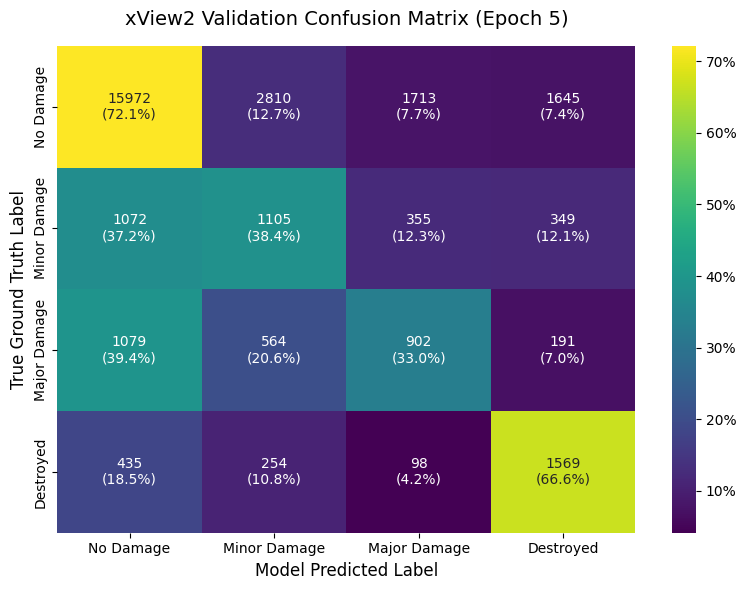

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.ticker as mtick

def generate_confusion_matrix(net, val_loader, checkpoints_path, model_name, epoch_to_load=5):
    #Reconstruct the file path for the target epoch checkpoint
    model_name_base = f'resnet50-{model_name}.ep{str(epoch_to_load).zfill(3)}.pth'
    checkpoint_file = checkpoints_path / 'checkpoints' / model_name_base

    print(f"Loading weights from checkpoint: {checkpoint_file}")
    net.load_state_dict(torch.load(checkpoint_file, map_location=device))

    #Switch model to evaluation mode
    net.eval()

    all_preds = []
    all_labels = []

    print("Evaluating validation set to collect predictions...")
    with torch.no_grad():
        for data in val_loader:
            inputs = data['image'].to(device)
            labels = data['label'].to(device)

            outputs = net(inputs)

            #Extract the highest scoring class prediction index
            predicted = outputs.argmax(dim=1)

            #Store values on CPU for scikit-learn processing
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    #Calculate the raw confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    #Calculate a normalized matrix to see percentage accuracies per class
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # 4. Plot the Matrix using Seaborn
    class_names = ['No Damage', 'Minor Damage', 'Major Damage', 'Destroyed']

    plt.figure(figsize=(8,6))

    #Annotate with both the raw count and the percentage breakdown
    labels_display = (np.array([f"{count}\n({percent:.1%})"
                       for count, percent in zip(cm.flatten(), cm_normalized.flatten())])).reshape(4, 4)

    ax=sns.heatmap(cm_normalized, annot=labels_display, fmt='', cmap='viridis',
                xticklabels=class_names, yticklabels=class_names)

    ax.collections[0].colorbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    plt.title(f'xView2 Validation Confusion Matrix (Epoch {epoch_to_load})', fontsize=14, pad=15)
    plt.ylabel('True Ground Truth Label', fontsize=12)
    plt.xlabel('Model Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

generate_confusion_matrix(net, val_loader, outputs, model_name, epoch_to_load=5)


In [18]:
import torch
import numpy as np
from sklearn.metrics import f1_score
from scipy.stats import hmean

def evaluate_advanced_f1_metrics(net, val_loader, checkpoints_path, model_name, epoch_to_load=5):
    model_name_base = f'resnet50-{model_name}.ep{str(epoch_to_load).zfill(3)}.pth'
    checkpoint_file = checkpoints_path / 'checkpoints' / model_name_base
    net.load_state_dict(torch.load(checkpoint_file, map_location=device))
    net.eval()

    val_preds = []
    val_targets = []

    print("Collecting validation predictions for advanced metrics...")
    with torch.no_grad():
        for data in val_loader:
            inputs = data['image'].to(device)
            labels = data['label'].to(device)

            with torch.amp.autocast(device_type='cuda', enabled=torch.cuda.is_available()):
                outputs = net(inputs)

            predicted = outputs.argmax(dim=1)
            val_preds.extend(predicted.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_preds = np.array(val_preds)
    val_targets = np.array(val_targets)

    # 2. Compute F1 Scores
    per_class_f1 = f1_score(val_targets, val_preds, average=None)
    macro_f1 = f1_score(val_targets, val_preds, average='macro')

    # Clip to prevent zero division if a class scores zero
    per_class_f1_safe = np.clip(per_class_f1, 1e-6, 1.0)
    harmonic_mean_f1 = hmean(per_class_f1_safe)

    print("\n" + "="*40)
    print("Xview2 evaluation metrics:")
    print("="*40)
    print(f"Overall Macro F1 Score:        {macro_f1:.4f}")
    print(f"Harmonic Mean of F1 Scores:    {harmonic_mean_f1:.4f}")
    print("-"*40)
    class_names = ['No Damage', 'Minor Damage', 'Major Damage', 'Destroyed']
    for idx, name in enumerate(class_names):
        print(f"-> {name.ljust(15)} F1 Score: {per_class_f1[idx]:.4f}")
    print("="*40)

evaluate_advanced_f1_metrics(net, val_loader, outputs, model_name, epoch_to_load=5)



Xview2 evaluation metrics:
Overall Macro F1 Score:        0.4743
Harmonic Mean of F1 Scores:    0.4039
----------------------------------------
-> No Damage       F1 Score: 0.7845
-> Minor Damage    F1 Score: 0.2905
-> Major Damage    F1 Score: 0.3089
-> Destroyed       F1 Score: 0.5132
